# Education Track Starter Notebook


# Question/Proposal : How has Financial Aid changed with time?

**Research Question : How has student Financial Aid changed with time?**

## Setup

In [ ]:
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

below, we are installing the trends in student aid data from College Board [here](https://research.collegeboard.org/trends/student-aid)

In [ ]:
!wget https://research.collegeboard.org/media/xlsx/Trends-in-Student-Aid-2025-excel-data_0.xlsx
!wget https://research.collegeboard.org/media/xlsx/Trends-in_College-Pricing-2025-excel-data.xlsx

--2026-03-28 03:24:04--  https://research.collegeboard.org/media/xlsx/Trends-in-Student-Aid-2025-excel-data_0.xlsx
Resolving research.collegeboard.org (research.collegeboard.org)... 104.19.144.148, 104.19.175.228, 2606:4700::6813:9094, ...
Connecting to research.collegeboard.org (research.collegeboard.org)|104.19.144.148|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1572022 (1.5M) [application/vnd.openxmlformats-officedocument.spreadsheetml.sheet]
Saving to: ‘Trends-in-Student-Aid-2025-excel-data_0.xlsx.3’

Trends-in-Student-A 100%[===================>]   1.50M  --.-KB/s    in 0.02s   

2026-03-28 03:24:05 (73.8 MB/s) - ‘Trends-in-Student-Aid-2025-excel-data_0.xlsx.3’ saved [1572022/1572022]

--2026-03-28 03:24:05--  https://research.collegeboard.org/media/xlsx/Trends-in_College-Pricing-2025-excel-data.xlsx
Resolving research.collegeboard.org (research.collegeboard.org)... 104.19.144.148, 104.19.175.228, 2606:4700::6813:9094, ...
Connecting to research.colle

using the data we just downloaded, we will store in memory as a dataframe using the Pandas library. The data we downloaded is an excel sheet, which is basically a collection of data tables

It may help to open the sheet in Google drive to view it for yourself. You'll notice that a lot of the text isn't actual data/ is there for appearance, which results in a lot of "--" and "NaN" values in our tables.

In [ ]:
file_path = '/content/Trends-in-Student-Aid-2025-excel-data_0.xlsx'
df = pd.read_excel(file_path, sheet_name="Table SA-1_ALL")

df

,"Table SA-1. Total Student Aid and Nonfederal Loans in 2024 Dollars (in Millions), Undergraduate and Graduate Students Combined, 1970-71 to 2024-25",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56
0,NaN,NaN,70-71,71-72,72-73,73-74,74-75,75-76,76-77,77-78,...,15-16,16-17,17-18,18-19,19-20,20-21,21-22,22-23,23-24,24-25 (Preliminary)
1,FEDERAL AID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Federal Grants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Pell Grants,--,--,--,336.2195,2280.149984,5399.170755,8134.104621,7890.572447,...,37797.374115,35150.28999,36692.263028,35489.715473,34867.814868,32078.119762,29948.679804,29170.584766,32392.358074,38642.161235
4,NaN,FSEOG,1330.75282,1373.547313,1578.200878,1485.783709,1338.109467,1401.105329,1323.629755,1294.577939,...,970.288277,958.199148,938.123606,1048.495304,1030.211623,1047.86096,1008.515287,971.517841,932.739423,906.374461
5,NaN,LEAP (ended 2010-11),--,--,--,--,120.258055,114.863816,240.917562,309.030252,...,--,--,--,--,--,--,--,--,--,--
6,NaN,Academic Competitiveness Grants (ended 2010-11),--,--,--,--,--,--,--,--,...,--,--,--,--,--,--,--,--,--,--
7,NaN,SMART Grants (ended 2010-11),--,--,--,--,--,--,--,--,...,--,--,--,--,--,--,--,--,--,--
8,NaN,Veterans and Military,9584.474675,9142.387567,14940.58239,16542.58679,21937.324736,24936.423166,17079.468069,14517.102723,...,16711.892968,15742.46179,14934.992747,14910.248195,14072.209879,12762.727548,11173.443178,11319.013074,12364.94695,14192.753
9,NaN,Total Federal Grants,10915.227495,10515.93488,16518.783268,18364.59,25675.842242,31851.563066,26778.120008,24011.283361,...,55479.55536,51850.950928,52565.379381,51448.458972,49970.23637,45888.708269,42130.638268,41461.11568,45690.044446,53741.288696


## Data Clean-up

In [ ]:
import pandas as pd

# reload the data frame, this time by removing some of the empty/unnecessary rows
df_clean = pd.read_excel(file_path, sheet_name='Table SA-1_ALL', skiprows=[0,2,3,11,18,22,27,29,30,31,32,33,34])

# The first column is the category name
df_clean = df_clean.rename(columns={df_clean.columns[0]: 'Category'})

# We use a lambda to rename the column label to whichever one exists
df_clean['Category'] = df_clean.apply(
    lambda row: f"{row['Unnamed: 1']}" if pd.notnull(row['Unnamed: 1']) else row['Category'],
    axis=1
)

# Move our new column to the front and drop the old ones
cols = ['Category'] + [c for c in df_clean.columns if c not in ['Category', 'Unnamed: 1', 'Category']]
df_clean = df_clean[cols]

df_clean


,Category,70-71,71-72,72-73,73-74,74-75,75-76,76-77,77-78,78-79,...,15-16,16-17,17-18,18-19,19-20,20-21,21-22,22-23,23-24,24-25 (Preliminary)
0,Pell Grants,--,--,--,336.2195,2280.149984,5399.170755,8134.104621,7890.572447,7413.524719,...,37797.374115,35150.28999,36692.263028,35489.715473,34867.814868,32078.119762,29948.679804,29170.584766,32392.358074,38642.161235
1,FSEOG,1330.75282,1373.547313,1578.200878,1485.783709,1338.109467,1401.105329,1323.629755,1294.577939,1298.840851,...,970.288277,958.199148,938.123606,1048.495304,1030.211623,1047.86096,1008.515287,971.517841,932.739423,906.374461
2,LEAP (ended 2010-11),--,--,--,--,120.258055,114.863816,240.917562,309.030252,305.99111,...,--,--,--,--,--,--,--,--,--,--
3,Academic Competitiveness Grants (ended 2010-11),--,--,--,--,--,--,--,--,--,...,--,--,--,--,--,--,--,--,--,--
4,SMART Grants (ended 2010-11),--,--,--,--,--,--,--,--,--,...,--,--,--,--,--,--,--,--,--,--
5,Veterans and Military,9584.474675,9142.387567,14940.58239,16542.58679,21937.324736,24936.423166,17079.468069,14517.102723,11030.846091,...,16711.892968,15742.46179,14934.992747,14910.248195,14072.209879,12762.727548,11173.443178,11319.013074,12364.94695,14192.753
6,Total Federal Grants,10915.227495,10515.93488,16518.783268,18364.59,25675.842242,31851.563066,26778.120008,24011.283361,20049.202771,...,55479.55536,51850.950928,52565.379381,51448.458972,49970.23637,45888.708269,42130.638268,41461.11568,45690.044446,53741.288696
7,Perkins Loans,1944.718189,2416.296022,2984.915934,3059.174257,2799.658418,2682.099257,3084.444948,3182.794192,3081.080301,...,1383.458527,1158.351726,806.990291,--,--,--,--,--,--,--
8,Subsidized Stafford,7185.218468,8640.125797,7694.604007,7046.061264,7231.583982,6468.446642,6396.012039,7872.865919,9941.915509,...,30380.459174,28300.947063,26755.706812,24754.504504,23118.741337,20068.161278,18184.266656,16539.960744,16118.037766,15342.384555
9,Unsubsidized Stafford,--,--,--,--,--,--,--,--,--,...,67131.680989,65242.151027,62413.389753,59861.271708,58427.319564,56143.419129,51291.163673,46928.059382,45106.79146,45362.653817


## Visualizations

Here is the graph of FSA vs. Year

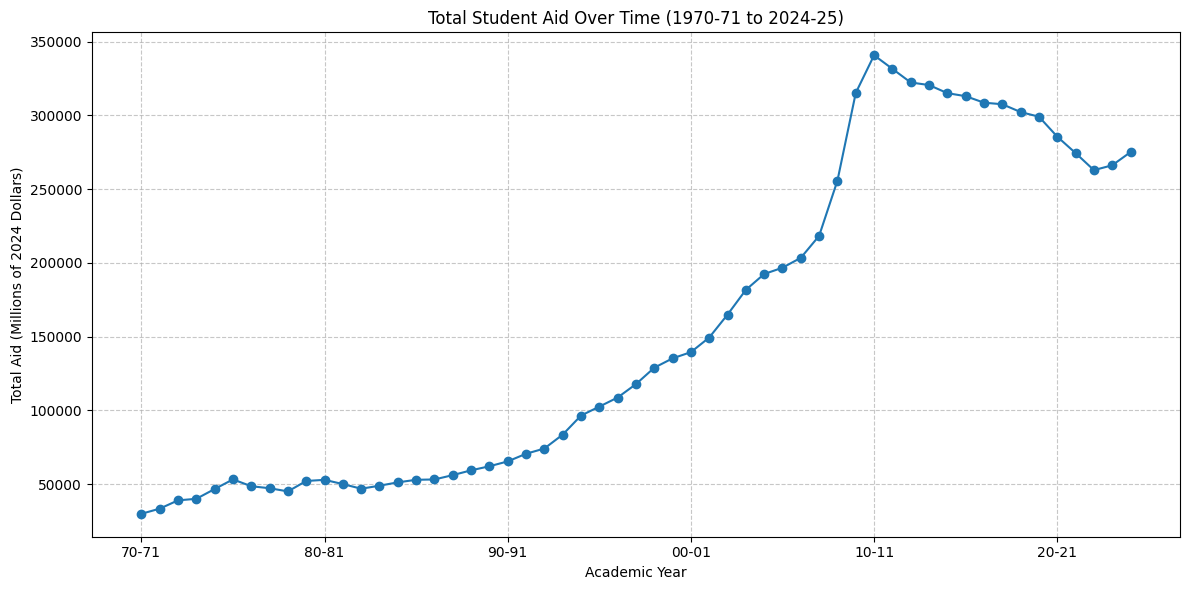

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identify the row for Total Aid
total_aid_row = df_clean[df_clean['Category'].str.contains('TOTAL FEDERAL, STATE', na=False)]

# 2. Transpose and prepare the data
# We skip the 'Category' column for the plot
plot_data = total_aid_row.set_index('Category').transpose()

# 3. Clean the data: replace '--' with NaN and convert to numeric
plot_data.columns = ['Total_Aid']
plot_data['Total_Aid'] = pd.to_numeric(plot_data['Total_Aid'].replace('--', pd.NA), errors='coerce')

# 4. Create the plot
plt.figure(figsize=(12, 6))
plot_data['Total_Aid'].plot(kind='line', marker='o')

plt.title('Total Student Aid Over Time (1970-71 to 2024-25)')
plt.xlabel('Academic Year')
plt.ylabel('Total Aid (Millions of 2024 Dollars)')
# plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Trends in College Pricing

In [ ]:
pricing_fp = "/content/Trends-in_College-Pricing-2025-excel-data.xlsx"
pricing_df = pd.read_excel(pricing_fp, sheet_name='Table CP-1')
pricing_df

,"Table CP-1. Average Published Prices (Enrollment-Weighted) for Full-Time Undergraduates, 2024-25 and 2025-26",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Trends in College Pricing 2025
0,NaN,Sector,NaN,NaN,NaN,NaN,Carnegie Classification,NaN,NaN,NaN,NaN,NaN,research.collegeboard.org/trends
1,NaN,Public Two-Year In-District,Public Four-Year In-State,Public Four-Year Out-of-State,Private Nonprofit Four-Year,For-Profit,Public Four-Year,NaN,NaN,Private Nonprofit Four-Year,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,Doctoral,Master’s,Bachelor’s,Doctoral,Master’s,Bachelor’s,NaN
3,Tuition and Fees,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-26,4150,11950,31880,45000,—,12720,9850,9240,54090,32600,46150,NaN
5,2024-25,4040,11610,30820,43250,"$16,030*",12360,9540,9010,51930,31330,44490,NaN
6,$ Change,110,340,1060,1750,—,360,310,230,2160,1270,1660,NaN
7,% Change,0.027228,0.029285,0.034393,0.040462,—,0.029126,0.032495,0.025527,0.041594,0.040536,0.037312,NaN
8,Housing and Food (Room and Board),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2025-26,10850,13900,13900,15920,—,14110,12230,12230,18330,14870,14740,NaN


now to clean this data up too

In [ ]:
# reload the data frame, this time by removing some of the empty/unnecessary rows
pricing_clean = pd.read_excel(pricing_fp, sheet_name='Table CP-1', skiprows=[0,1])
pricing_clean.drop(pricing_clean.columns[-1], axis=1, inplace=True)


In [ ]:
import re
needle = r"Unnamed: \d"
filled_names = {}

j = 0
for i,col in enumerate(pricing_clean.columns):
  if re.match(needle, col) and i > 0:
    filled_names[col] = pricing_clean.columns[j]
  else:
    filled_names[col] = col
    j = i

pricing_clean = pricing_clean.rename(columns=filled_names)
pricing_clean


,Unnamed: 0,Public Two-Year In-District,Public Four-Year In-State,Public Four-Year Out-of-State,Private Nonprofit Four-Year,For-Profit,Public Four-Year,Public Four-Year,Public Four-Year,Private Nonprofit Four-Year.1,Private Nonprofit Four-Year.1,Private Nonprofit Four-Year.1
0,NaN,NaN,NaN,NaN,NaN,NaN,Doctoral,Master’s,Bachelor’s,Doctoral,Master’s,Bachelor’s
1,Tuition and Fees,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-26,4150.000000,11950.000000,31880.000000,45000.000000,—,12720,9850,9240,54090,32600,46150
3,2024-25,4040.000000,11610.000000,30820.000000,43250.000000,"$16,030*",12360,9540,9010,51930,31330,44490
4,$ Change,110.000000,340.000000,1060.000000,1750.000000,—,360,310,230,2160,1270,1660
5,% Change,0.027228,0.029285,0.034393,0.040462,—,0.029126,0.032495,0.025527,0.041594,0.040536,0.037312
6,Housing and Food (Room and Board),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-26,10850.000000,13900.000000,13900.000000,15920.000000,—,14110,12230,12230,18330,14870,14740
8,2024-25,10390.000000,13310.000000,13310.000000,15250.000000,—,13450,11760,11740,17540,14260,14120
9,Tuition and Fees and Housing and Food,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


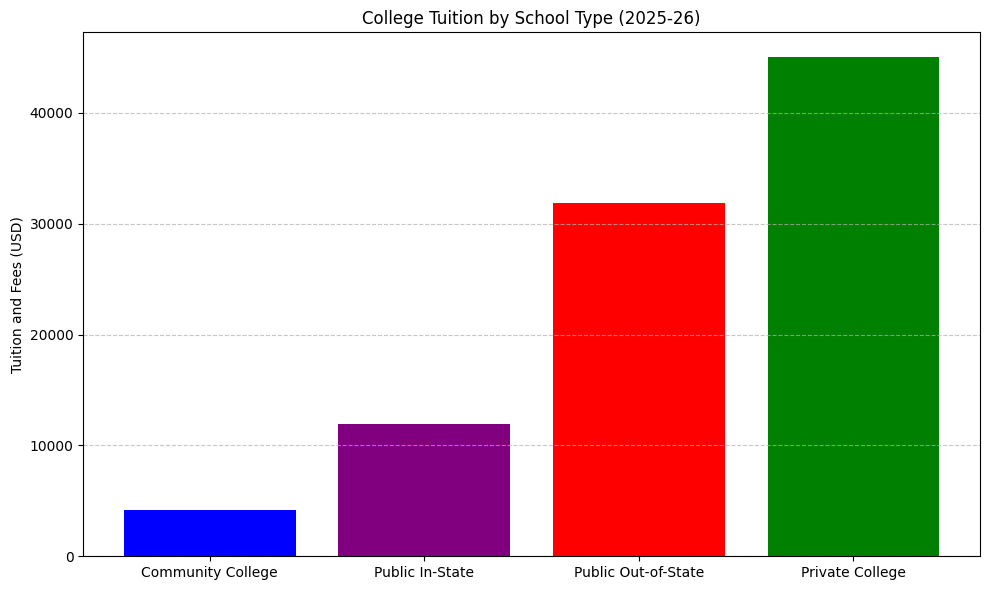

In [ ]:
latest = pricing_clean[pricing_clean['Unnamed: 0'] == '2025-26']

#each school type's tuition
community = latest['Public Two-Year In-District'].values[0]
instate   = latest['Public Four-Year In-State'].values[0]
outstate  = latest['Public Four-Year Out-of-State'].values[0]
private   = latest['Private Nonprofit Four-Year'].values[0]

#make the plot
labels = ['Community College', 'Public In-State', 'Public Out-of-State', 'Private College']
values = [community, instate, outstate, private]
colors = ['blue', 'purple', 'red', 'green']

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=colors)
plt.title('College Tuition by School Type (2025-26)')
plt.ylabel('Tuition and Fees (USD)')
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()